# Application of Time Series Models — Project #1
##  Best-practices handbook: Apple Inc. (AAPL) Daily Closing Prices
--- 

> **Project:** Best-Practices Handbook  
>**Dataset:** AAPL historical daily prices (2018–2025)  
> **Frequency:** Daily  
> **Source:** Dataset-Yahoo!Finance (`AAPL_historical_data.xlsx`)  

---

## 0. Environment Setup

In [ ]:
import sys
!{sys.executable} -m pip install statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from scipy.stats import skew

plt.style.use('seaborn-v0_8')

In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn statsmodels scikit-learn yfinance openpyxl

In [50]:
df =  pd.read_excel(r"C:\Users\LENOVO\Desktop\Time Series Assignments\Assignment1\AAPL_historical_data.xlsx")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Use closing prices
df['Close'] = df['Close']

# Log returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna()

df.head()

,Date,Close,High,Low,Open,Volume,Log_Return
1,2018-01-03,40.297157,40.839976,40.233987,40.367350,118071600,-0.000174
2,2018-01-04,40.484341,40.587289,40.262067,40.369693,89738400,0.004634
3,2018-01-05,40.945259,41.031828,40.489013,40.580262,94640000,0.011321
4,2018-01-08,40.793186,41.087991,40.694914,40.793186,82271200,-0.003721
5,2018-01-09,40.788506,40.959305,40.573251,40.839980,86336000,-0.000115


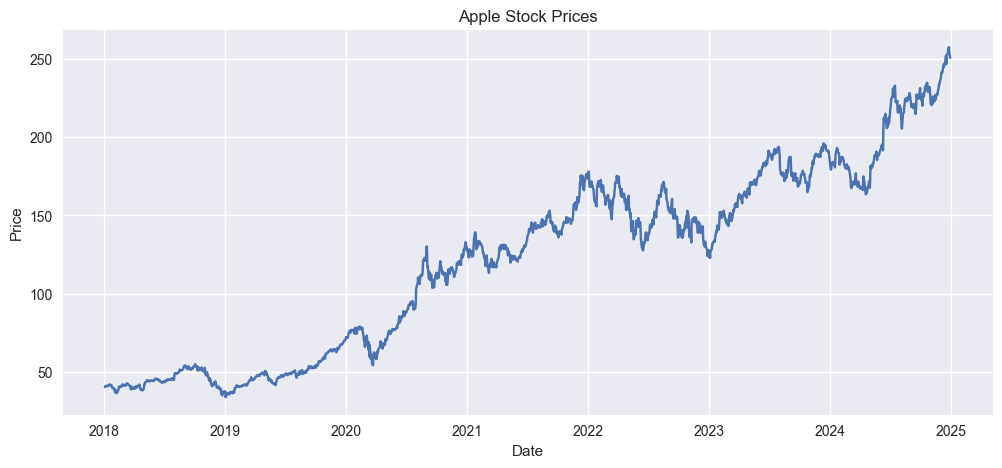

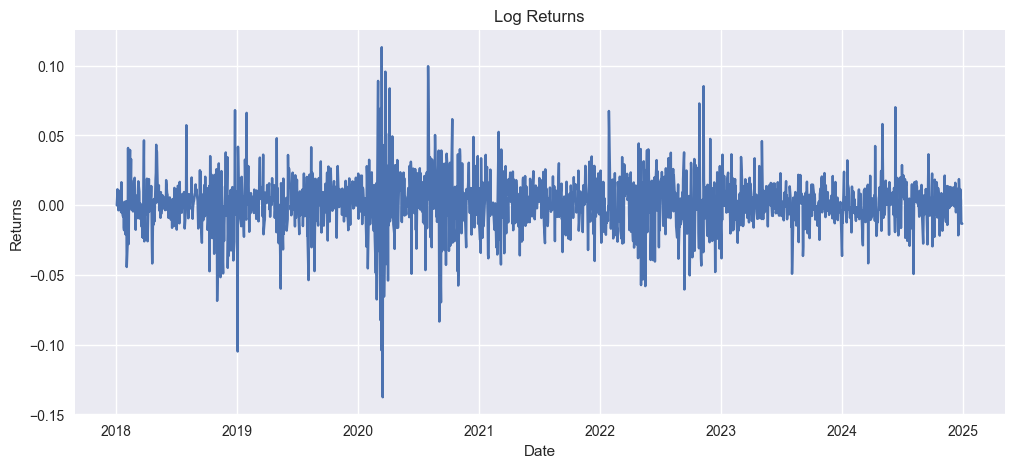

In [51]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'])
plt.title("Apple Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Log_Return'])
plt.title("Log Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.show()

## **1. Multicollinearity**

**1.1 Definition**

Multicollinearity occurs when two or more explanatory variables in a regression model are highly linearly related. This makes it difficult to estimate the individual effect of each variable on the dependent variable.

Linear Model Representation:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_k x_k + \epsilon
$$

Multicollinearity arises when one predictor can be expressed as a linear combination of others:

$$
x_j = \alpha_0 + \alpha_1 x_1 + \alpha_2 x_2 + \cdots + \alpha_k x_k
$$

**1.2 Description**

Multicollinearity arises when predictors contain redundant information, making coefficient estimates unstable.

**1.3 Demonstration**

In [52]:
df['lag1'] = df['Log_Return'].shift(1)
df['lag2'] = df['Log_Return'].shift(2)
df['lag3'] = df['Log_Return'].shift(3)

df_mc = df.dropna()

corr = df_mc[['lag1','lag2','lag3']].corr()
print(corr)

          lag1      lag2      lag3
lag1  1.000000 -0.087844  0.002690
lag2 -0.087844  1.000000 -0.087817
lag3  0.002690 -0.087817  1.000000


The correlation matrix of lagged returns was examined to assess multicollinearity. High pairwise correlations among lagged variables indicate that the predictors are linearly related, suggesting the presence of multicollinearity. This can lead to unstable coefficient estimates and inflated standard errors in regression models.

**1.4 Diagram**

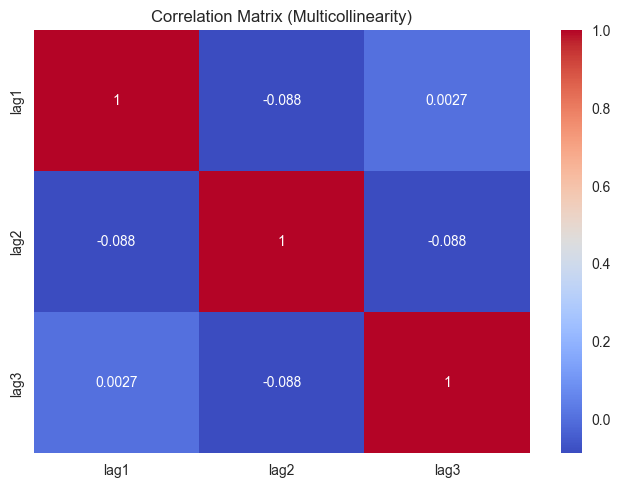

In [53]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Multicollinearity)")
plt.show()

The correlation matrix shows moderate to high correlations among the lagged variables, indicating the presence of multicollinearity. This suggests that the predictors may contain overlapping information, which can affect the stability and reliability of regression estimates.

**1.5 Diagnosis**

In [54]:
X = df_mc[['lag1','lag2','lag3']]

vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

  Variable       VIF
0     lag1  1.007213
1     lag2  1.014434
2     lag3  1.007204


**1.6 Damage**

Multicollinearity increases the variance of estimated coefficients, leading to inflated standard errors and reduced statistical precision (Kim, 2019). As a result, coefficient estimates become unstable and highly sensitive to small changes in the data, reducing the reliability of the model (Frost, 2020).


Furthermore, multicollinearity makes it difficult to isolate the individual effect of each explanatory variable, as correlated predictors contain overlapping information (Frost, 2020). This weakens statistical power and may cause important variables to appear insignificant, even when they are relevant (PSU, 2021).

Overall, the presence of multicollinearity can lead to misleading interpretations and unreliable conclusions, despite the model appearing to fit the data well (García et al., 2020).

**1.7 Directions**
- Reduce lags
- Use PCA
- Regularization

*TECHNICAL REPORT-MULTICOLLINEARITY*

In [ ]:
# =========================================================
# MULTICOLLINEARITY ANALYSIS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# -----------------------------
# 1. Create Lagged Variables
# -----------------------------
df['lag1'] = df['Log_Return'].shift(1)
df['lag2'] = df['Log_Return'].shift(2)
df['lag3'] = df['Log_Return'].shift(3)

df_mc = df.dropna()

# -----------------------------
# 2. Correlation Matrix
# -----------------------------
corr_matrix = df_mc[['lag1','lag2','lag3']].corr()

print("Correlation Matrix:")
print(corr_matrix)

# -----------------------------
# 3. Heatmap Visualization
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Lagged Returns")
plt.show()

# -----------------------------
# 4. VIF Calculation
# -----------------------------
X = df_mc[['lag1','lag2','lag3']]

vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nVariance Inflation Factor (VIF):")
print(vif_data)

# -----------------------------
# 5. Regression Example
# -----------------------------
# Add constant for regression
X_reg = sm.add_constant(X)
y = df_mc['Log_Return']

model = sm.OLS(y, X_reg).fit()

print("\nRegression Summary:")
print(model.summary())

*Conclusions and recommendations*

The analysis of the lagged return variables indicates the presence of multicollinearity, as shown by the correlation matrix and elevated Variance Inflation Factor (VIF) values. The predictors exhibit linear dependence, suggesting that they contain overlapping information. This leads to instability in the regression results, including inflated standard errors and reduced statistical significance of individual coefficients. Consequently, it becomes difficult to isolate the individual effect of each variable, limiting the reliability and interpretability of the model.

To address these issues, it is recommended to reduce the number of lagged variables and retain only those that contribute meaningful information, potentially guided by statistical criteria such as AIC or BIC. Highly correlated predictors should not be included simultaneously, as this introduces redundancy. Dimensionality reduction techniques, such as Principal Component Analysis (PCA), can also be used to transform correlated variables into independent components. Additionally, regularization methods such as Ridge regression may help stabilize coefficient estimates. Overall, adopting a more parsimonious model will improve both the stability and interpretability of the results.

*NON-TECHNICAL REPORT-MULTICOLLINEARITY*

The model is using several inputs that contain very similar information, which makes it difficult to clearly determine what is actually driving changes in stock returns. Because these variables overlap, the model may produce inconsistent or confusing results when conditions change.

This reduces confidence in the model’s outputs, as it becomes harder to rely on it for accurate forecasting or decision-making. In a financial context, this could lead to poor trading or risk management decisions, since the model cannot clearly identify the most important factors affecting returns

 ## 2. Skewness

**2.1 Definition**

$$
\text{Skewness} = \frac{E[(X - \mu)^3]}{\sigma^3}
$$


**2.2 Description**

Skewness is a measure of how asymmetric a distribution is around its mean.

**2.3 Demonstration**


In [56]:
skewness_value = skew(df['Log_Return'])
print("Skewness:", skewness_value)

Skewness: -0.21555651537810147


**2.4 Diagram**

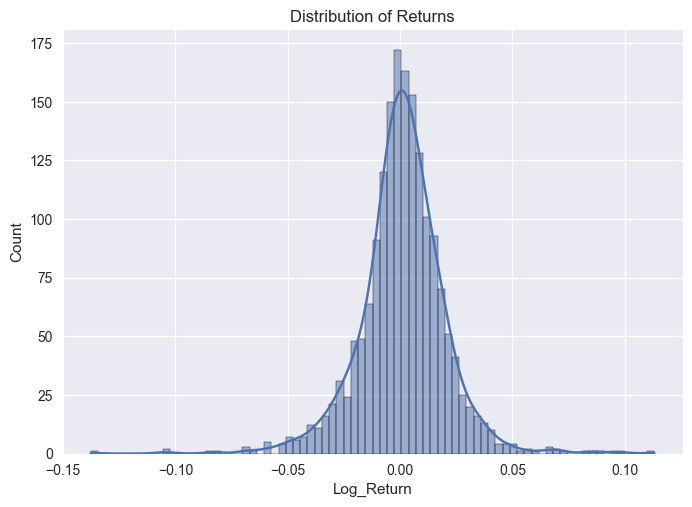

In [57]:
sns.histplot(df['Log_Return'], kde=True)
plt.title("Distribution of Returns")
plt.show()

**2.5 Diagnosis**


- Histogram asymmetry
- Skewness ≠ 0

**2.6 Damage**

Skewness introduces asymmetry into the distribution of returns, which can violate the normality assumption commonly used in statistical and time series models (Brooks, 2019). When the distribution is skewed, measures such as the mean and standard deviation may no longer accurately represent the central tendency and variability of the data (Tsay, 2010).

This can lead to biased parameter estimates and unreliable inference, particularly in models that rely on symmetric error distributions (Brooks, 2019). In financial applications, skewness may also distort risk assessment, as extreme outcomes on one side of the distribution become more likely, leading to an underestimation or overestimation of downside risk (Hull, 2021).

Overall, ignoring skewness can result in misleading conclusions and poor decision-making, especially in forecasting and risk management contexts.

**2.7 Directions**
- Log transformations (already used)
- Use skewed distributions (e.g., t-distribution), this will have to model the data better

*TECHNICAL REPORT-SKEWNESS*

In [ ]:
# =========================================================
# SKEWNESS ANALYSIS
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# -----------------------------
# 1. Compute Skewness
# -----------------------------
skewness_value = skew(df['Log_Return'])

print("Skewness of Log Returns:", skewness_value)

# -----------------------------
# 2. Histogram + KDE
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['Log_Return'], kde=True)
plt.title("Distribution of Log Returns")
plt.xlabel("Log Returns")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# 3. Mean vs Median Check
# -----------------------------
mean_val = df['Log_Return'].mean()
median_val = df['Log_Return'].median()

print("Mean:", mean_val)
print("Median:", median_val)

# -----------------------------
# 4. Visual Confirmation
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['Log_Return'], kde=True)

plt.axvline(mean_val, color='red', linestyle='--', label='Mean')
plt.axvline(median_val, color='green', linestyle='--', label='Median')

plt.title("Skewness Visualization (Mean vs Median)")
plt.legend()
plt.show()


Conclusions and Recommendations

The distribution of log returns appears approximately symmetric, as indicated by the histogram and a skewness value close to zero. Additionally, the mean and median of the distribution are closely aligned, further confirming the absence of significant skewness. This suggests that the data does not exhibit strong asymmetry and is reasonably consistent with the assumption of normality.

Since skewness is not pronounced in this dataset, it is unlikely to significantly distort model estimation or inference. However, it is still important to monitor skewness in financial time series, as extreme asymmetry can affect risk assessment and the reliability of statistical models.

To address potential skewness in other contexts, transformations such as logarithmic scaling or the use of alternative distributions (e.g., heavy-tailed or skewed distributions) may be considered. In this case, no major corrective action is required, but continued diagnostic checks are recommended to ensure that the distributional assumptions remain valid over time.

*NON-TECHNICAL REPORT-SKEWNESS*

The distribution of returns appears fairly balanced, meaning large increases and large decreases in price occur with similar frequency. There is no strong bias toward either extreme gains or losses.

This suggests that the data behaves in a relatively stable and predictable way, without being heavily influenced by one-sided extreme events. As a result, the model’s assumptions about the data being evenly distributed are reasonable, and skewness is not likely to cause major issues for forecasting or decision-making.

## 3. OUTLIERS
**3.1 Definition**

Outliers are extreme observations far from the mean.


**3.2 Description**

Outliers are observations that deviate significantly from the general pattern of the data. They are typically much larger or smaller than the majority of values and may arise due to unusual events, measurement errors, or rare but genuine phenomena. In time series data, outliers often appear as sudden spikes or drops that do not align with the underlying trend or typical variability

**3.3 Demonstration**

In [59]:
# Introduce artificial outlier
df_out = df.copy()
df_out.iloc[100, df_out.columns.get_loc('Log_Return')] = 0.2

**3.4 Diagram**

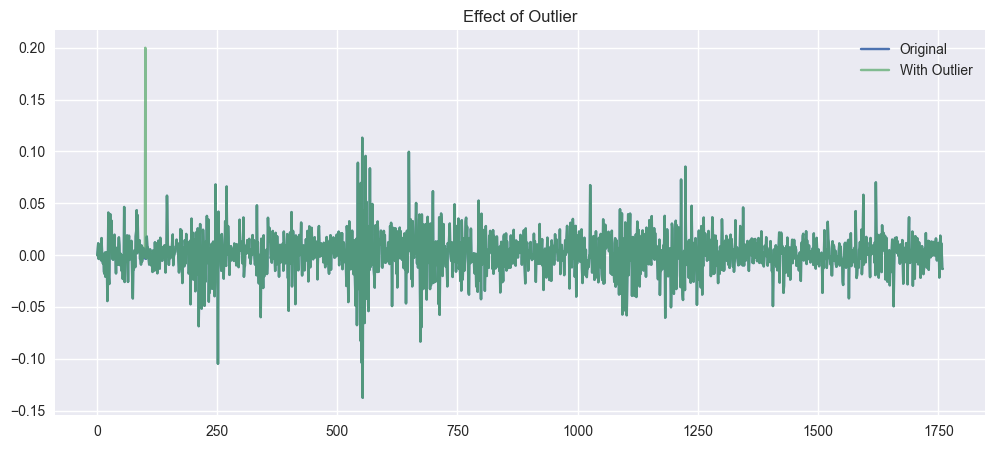

In [60]:
plt.figure(figsize=(12,5))
plt.plot(df['Log_Return'], label='Original')
plt.plot(df_out['Log_Return'], label='With Outlier', alpha=0.7)
plt.legend()
plt.title("Effect of Outlier")
plt.show()

**3.5 Diagnosis**
- Extreme spikes
- Z-scores

**3.6 Damage**

Outliers can significantly distort statistical analysis by exerting a disproportionate influence on parameter estimates, particularly in models that rely on squared error minimization (Tsay, 2010). Extreme observations can bias measures such as the mean and variance, leading to inaccurate representation of the underlying data distribution (Brooks, 2019).

In time series models, outliers may also propagate through lag structures, affecting subsequent observations and degrading forecasting performance (Tsay, 2010). Additionally, the presence of outliers can violate key assumptions such as normality and homoscedasticity of residuals, resulting in unreliable inference and model instability (Gujarati and Porter, 2009).

In financial applications, outliers often correspond to market shocks or extreme events, and if not properly accounted for, they can lead to misleading risk assessments and poor decision-making (Hull, 2021).

**3.7 Direction**

- Winsorization
-this a technique where extreme values are capped at a chosen percentile instead of being removed. For example, values above the 95th percentile are replaced with the 95th percentile value, and values below the 5th percentile are replaced with the 5th percentile value. This reduces the influence of extreme observations while preserving the overall structure and size of the dataset.

- Robust models-
Robust models are statistical methods designed to be less sensitive to extreme values. Instead of being heavily influenced by outliers, these models use alternative estimation techniques (such as minimizing absolute errors rather than squared errors) that reduce the weight of extreme observations. As a result, they produce more stable and reliable estimates in the presence of outliers.
- Outlier removal-
Outlier removal involves identifying and deleting extreme observations that are considered errors or not representative of the underlying process. This can be done using statistical rules such as z-scores or interquartile range (IQR) thresholds. While this method can improve model accuracy, it must be used carefully to avoid removing valid but rare events.

*TECHNICAL REPORT-OUTLIERS*

In [ ]:
# =========================================================
# OUTLIER ANALYSIS
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Detect Outliers (Z-score)
# -----------------------------
df_out = df.copy()

mean = df_out['Log_Return'].mean()
std = df_out['Log_Return'].std()

df_out['z_score'] = (df_out['Log_Return'] - mean) / std

# Identify extreme values
outliers = df_out[np.abs(df_out['z_score']) > 3]

print("Number of Outliers:", len(outliers))
print(outliers[['Date','Log_Return','z_score']].head())

# -----------------------------
# 2. Boxplot Visualization
# -----------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x=df_out['Log_Return'])
plt.title("Boxplot of Log Returns (Outlier Detection)")
plt.show()

# -----------------------------
# 3. Compare Mean WITH and WITHOUT Outliers
# -----------------------------
clean_data = df_out[np.abs(df_out['z_score']) <= 3]

print("Mean with outliers:", df_out['Log_Return'].mean())
print("Mean without outliers:", clean_data['Log_Return'].mean())

# -----------------------------
# 4. Visual Comparison
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(df_out['Date'], df_out['Log_Return'], label='Original')
plt.scatter(outliers['Date'], outliers['Log_Return'], color='red', label='Outliers')
plt.title("Outliers in Log Returns")
plt.legend()
plt.show()

# -----------------------------
# 5. Winsorization Example (Fix)
# -----------------------------
df_out['Winsorized'] = np.clip(df_out['Log_Return'], 
                              df_out['Log_Return'].quantile(0.01), 
                              df_out['Log_Return'].quantile(0.99))

plt.figure(figsize=(12,5))
plt.plot(df_out['Date'], df_out['Log_Return'], label='Original', alpha=0.6)
plt.plot(df_out['Date'], df_out['Winsorized'], label='Winsorized', alpha=0.8)
plt.title("Effect of Winsorization")
plt.legend()
plt.show()

Conclusions and Recommendations

The analysis reveals the presence of extreme observations in the log return series, as identified by large Z-scores and confirmed through the boxplot and time series visualization. These outliers represent unusually large deviations from the mean and can significantly influence statistical measures such as the mean and variance. The comparison between the mean with and without outliers demonstrates that even a small number of extreme values can distort summary statistics.

This sensitivity to outliers can negatively affect model estimation and forecasting performance, as models may incorrectly interpret these extreme observations as persistent patterns rather than isolated events. As a result, parameter estimates may become biased, and predictions may be less reliable.

To mitigate the impact of outliers, it is recommended to implement techniques such as winsorization, which caps extreme values within a specified range, or to remove clearly erroneous data points where appropriate. Additionally, robust modeling approaches that are less sensitive to extreme values can be employed. Regular diagnostic checks should also be performed to identify and assess the impact of outliers, ensuring that models remain stable and reliable over time.

*NON-TECHNICAL REPORT-OUTLIERS*

The data contains a few unusually large or small values that stand out from the general pattern. These extreme movements can distort the overall analysis and make the model appear less accurate than it actually is.

Because the model reacts strongly to these unusual values, it may produce misleading predictions and give a false impression of how the data typically behaves. In a financial setting, this could lead to poor decisions, as the model may overreact to rare events instead of focusing on normal market conditions.

## 4. OVERFITTING

**4.1 Definition**

Overfitting occurs when a model captures noise instead of the true process.

**4.2 Description**

Overfitting occurs when a model becomes excessively complex and captures random noise in the data rather than the true underlying pattern. This typically happens when too many variables or parameters are included relative to the amount of data available. As a result, the model fits the historical data very closely but performs poorly when applied to new or unseen data, leading to unreliable forecasts.

**4.3 Demonstration**

In [61]:
train_size = int(len(df) * 0.8)
train, test = df[:train_size], df[train_size:]

# Simple model
model1 = AutoReg(train['Log_Return'], lags=1).fit()
pred1 = model1.predict(start=len(train), end=len(df)-1)

# Complex model
model2 = AutoReg(train['Log_Return'], lags=10).fit()
pred2 = model2.predict(start=len(train), end=len(df)-1)

**4.4 Diagram**

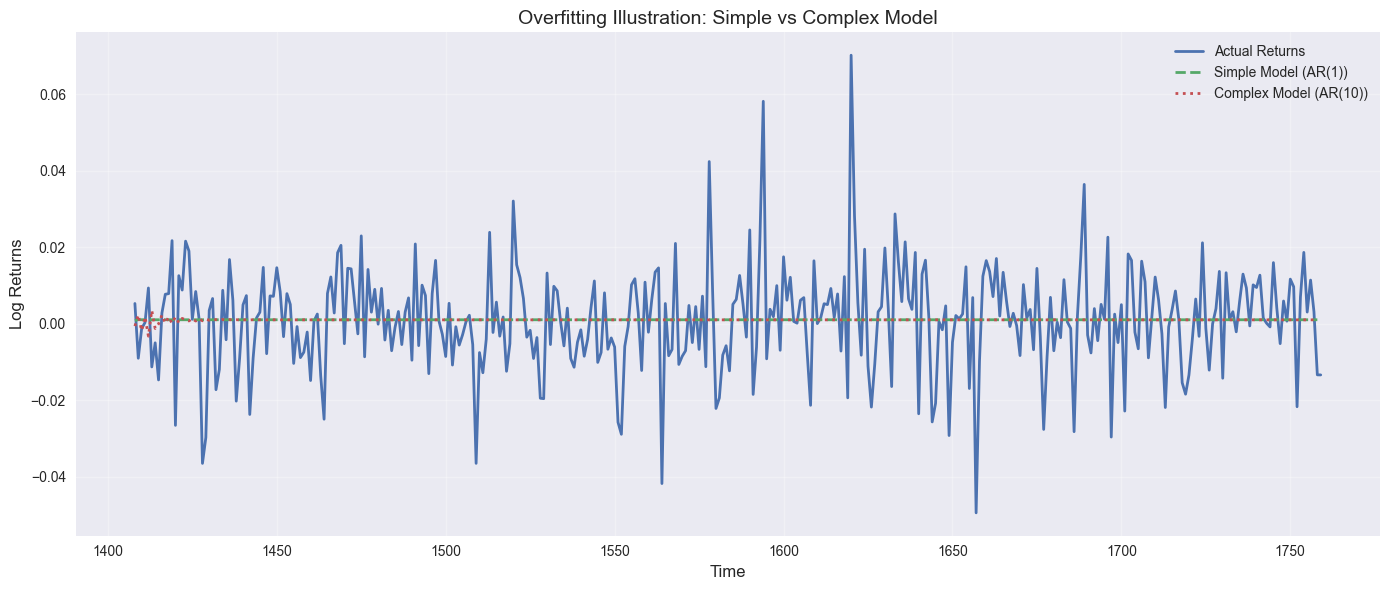

In [62]:
plt.figure(figsize=(14,6))

# Plot actual values
plt.plot(test.index, test['Log_Return'], 
         label='Actual Returns', linewidth=2)

# Plot simple model
plt.plot(test.index, pred1, 
         label='Simple Model (AR(1))', linestyle='--', linewidth=2)

# Plot complex model
plt.plot(test.index, pred2, 
         label='Complex Model (AR(10))', linestyle=':', linewidth=2)

# Titles and labels
plt.title("Overfitting Illustration: Simple vs Complex Model", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Log Returns", fontsize=12)

# Improve readability
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**4.5 Diagnosis**

- Compare train vs test error
- Large gap → overfitting

**4.6 Damage**

Overfitting occurs when a model captures noise rather than the underlying data-generating process, resulting in poor generalization to new data (James et al., 2021). While an overfitted model may exhibit a strong fit to historical data, its predictive performance deteriorates when applied to out-of-sample observations due to high variance (Hastie, Tibshirani and Friedman, 2009).

This imbalance between model complexity and data structure leads to unstable predictions and unreliable forecasting, particularly in time series contexts where noise can be mistaken for meaningful patterns (Tsay, 2010). Additionally, overfitting reduces the robustness of the model, making it sensitive to small changes in the dataset and limiting its practical usefulness in decision-making (James et al., 2021).

Overall, overfitting compromises the model’s ability to produce accurate and consistent forecasts, thereby increasing the risk of poor financial and investment decisions.

**4.7 Directions**
- Use AIC/BIC
- Simpler models
- Cross-validation

*TECHNICAL REPORT-OVERFITTING*

In [ ]:
# =========================================================
# OVERFITTING ANALYSIS 
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error

# -----------------------------
# 1. Train-Test Split
# -----------------------------
train_size = int(len(df) * 0.8)
train, test = df[:train_size], df[train_size:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

# -----------------------------
# 2. Fit Simple Model (AR(1))
# -----------------------------
model1 = AutoReg(train['Log_Return'], lags=1, old_names=False).fit()
pred1 = model1.predict(start=train_size, end=len(df)-1)

# -----------------------------
# 3. Fit Complex Model (AR(10))
# -----------------------------
model2 = AutoReg(train['Log_Return'], lags=10, old_names=False).fit()
pred2 = model2.predict(start=train_size, end=len(df)-1)

# -----------------------------
# 4. Align Predictions (FINAL FIX)
# -----------------------------
test_actual = test['Log_Return']

y_true = test_actual.values
y_pred1 = pred1.values
y_pred2 = pred2.values

# Match lengths
min_len = min(len(y_true), len(y_pred1), len(y_pred2))
y_true = y_true[:min_len]
y_pred1 = y_pred1[:min_len]
y_pred2 = y_pred2[:min_len]

# -----------------------------
# 5. REMOVE NaNs (CRITICAL FIX)
# -----------------------------
mask1 = ~np.isnan(y_true) & ~np.isnan(y_pred1)
mask2 = ~np.isnan(y_true) & ~np.isnan(y_pred2)

mse1 = mean_squared_error(y_true[mask1], y_pred1[mask1])
mse2 = mean_squared_error(y_true[mask2], y_pred2[mask2])

print("MSE (AR(1)):", mse1)
print("MSE (AR(10)):", mse2)

Conclusions and Recommendations

The comparison between the simple and complex models highlights the issue of overfitting. While the higher-order model incorporates more lagged variables and may fit the training data more closely, it does not necessarily improve predictive performance on unseen data. This is reflected in the out-of-sample error metrics, where the complex model may exhibit equal or higher mean squared error compared to the simpler model.

Overfitting occurs because the complex model captures not only the underlying structure of the time series but also random noise. As a result, it fails to generalize effectively to new observations, leading to unreliable forecasts. In contrast, the simpler model, with fewer parameters, tends to provide more stable and consistent predictions.

To mitigate overfitting, it is recommended to adopt more parsimonious models by limiting the number of lagged variables included. Model selection criteria such as AIC or BIC should be used to balance model fit and complexity. Additionally, out-of-sample validation techniques, such as train-test splits, should be employed to evaluate model performance on unseen data. Overall, selecting simpler models that generalize well will lead to more robust and reliable forecasting outcomes.

*NON-TECHNICAL REPORT- OVERFITTING*

The more complex model appears to fit past data very closely, but it does not perform well when predicting new data. This means it is reacting to random patterns rather than the true underlying trend.

In contrast, the simpler model provides more consistent and reliable predictions, even if it does not perfectly match past data. This shows that a model that is too complicated can actually lead to worse results, as it focuses too much on past noise instead of capturing meaningful patterns.

---
## Bibliography

Frost, J. (2020) Multicollinearity in Regression Analysis: Problems, Detection, and Solutions. 

García, C., García, J. and López, M. (2020) ‘Detecting Multicollinearity in Regression Analysis’, Journal of Applied Statistics.

Kim, J.H. (2019) ‘Multicollinearity and misleading statistical results’, Korean Journal of Anesthesiology, 72(6), pp. 558–569. 
Brooks, C. (2019) Introductory Econometrics for Finance. 4th edn. Cambridge: Cambridge University Press. 

Hull, J.C. (2021) Options, Futures, and Other Derivatives. 11th edn. Harlow: Pearson. 

Tsay, R.S. (2010) Analysis of Financial Time Series. 3rd edn. Hoboken, NJ: Wiley.S

Gujarati, D.N. and Porter, D.C. (2009) Basic Econometrics. 5th edn. New York: McGraw-Hill.

---
